In [1]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_black(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0):
    """
    Change mask background to black and save to separate folder
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to BLACK (0,0,0) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [0, 0, 0]  # Black
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename}")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Processed masks saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1"  # Replace with your input folder path
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg"  # Replace with your desired output folder
    
    # For exact color matching (100,100,100)
    change_mask_background_to_black(input_folder, output_folder, 
                                   background_color=(100, 100, 100), 
                                   tolerance=0)
    
    # If you need tolerance for slight color variations, use this instead:
    # change_mask_background_to_black(input_folder, output_folder, 
    #                                background_color=(100, 100, 100), 
    #                                tolerance=5)

Found 630 images to process
✓ Processed: 251.png
✓ Processed: 542.png
✓ Processed: 8.png
✓ Processed: 233.png
✓ Processed: 611.png
✓ Processed: 302.png
✓ Processed: 73.png
✓ Processed: 424.png
✓ Processed: 103.png
✓ Processed: 247.png
✓ Processed: 180.png
✓ Processed: 583.png
✓ Processed: 264.png
✓ Processed: 606.png
✓ Processed: 6.png
✓ Processed: 421.png
✓ Processed: 130.png
✓ Processed: 228.png
✓ Processed: 450.png
✓ Processed: 96.png
✓ Processed: 236.png
✓ Processed: 33.png
✓ Processed: 609.png
✓ Processed: 11.png
✓ Processed: 275.png
✓ Processed: 591.png
✓ Processed: 54.png
✓ Processed: 528.png
✓ Processed: 182.png
✓ Processed: 32.png
✓ Processed: 570.png
✓ Processed: 299.png
✓ Processed: 430.png
✓ Processed: 575.png
✓ Processed: 480.png
✓ Processed: 473.png
✓ Processed: 131.png
✓ Processed: 262.png
✓ Processed: 47.png
✓ Processed: 344.png
✓ Processed: 574.png
✓ Processed: 486.png
✓ Processed: 51.png
✓ Processed: 311.png
✓ Processed: 621.png
✓ Processed: 628.png
✓ Processed: 250.p

In [6]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def create_bounding_boxes_around_points(input_folder, output_folder, background_color=(100, 100, 100), box_size=10, tolerance=0):
    """
    Create small bounding boxes around non-background points and save to separate folder
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed images with bounding boxes will be saved
        background_color: The RGB color to consider as background
        box_size: Size of the bounding boxes (half-size from center, so actual box is 2*box_size + 1)
        tolerance: Color tolerance for background detection
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Read image
            img = cv2.imread(input_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Create mask for non-background pixels (points of interest)
            if tolerance == 0:
                # Exact match for background
                non_bg_mask = ~((img_rgb[:,:,0] == background_color[0]) & 
                               (img_rgb[:,:,1] == background_color[1]) & 
                               (img_rgb[:,:,2] == background_color[2]))
            else:
                # With tolerance
                color_diff = np.abs(img_rgb - np.array(background_color))
                bg_mask = np.all(color_diff <= tolerance, axis=2)
                non_bg_mask = ~bg_mask
            
            # Find coordinates of non-background points
            y_coords, x_coords = np.where(non_bg_mask)
            
            # Create result image with black background
            result_img = np.zeros_like(img_rgb)
            
            # Draw bounding boxes around each point
            for y, x in zip(y_coords, x_coords):
                # Calculate box coordinates
                y1 = max(0, y - box_size)
                y2 = min(img_rgb.shape[0], y + box_size + 1)
                x1 = max(0, x - box_size)
                x2 = min(img_rgb.shape[1], x + box_size + 1)
                
                # Draw white box
                result_img[y1:y2, x1:x2] = [255, 255, 255]  # White box
            
            # Convert back to BGR and save
            result_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, result_bgr)
            
            print(f"✓ Processed: {filename} - Found {len(y_coords)} points")
            
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Images with bounding boxes saved to: {output_folder}")

def create_bounding_boxes_preserve_points(input_folder, output_folder, background_color=(100, 100, 100), box_size=10, tolerance=0):
    """
    Alternative version: Keep original points AND draw bounding boxes around them
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Read image
            img = cv2.imread(input_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Create mask for non-background pixels
            if tolerance == 0:
                non_bg_mask = ~((img_rgb[:,:,0] == background_color[0]) & 
                               (img_rgb[:,:,1] == background_color[1]) & 
                               (img_rgb[:,:,2] == background_color[2]))
            else:
                color_diff = np.abs(img_rgb - np.array(background_color))
                bg_mask = np.all(color_diff <= tolerance, axis=2)
                non_bg_mask = ~bg_mask
            
            # Find coordinates of non-background points
            y_coords, x_coords = np.where(non_bg_mask)
            
            # Start with black background
            result_img = np.zeros_like(img_rgb)
            
            # First, copy the original points
            result_img[non_bg_mask] = img_rgb[non_bg_mask]
            
            # Then draw bounding boxes around each point
            box_color = [255, 255, 255]  # White boxes
            for y, x in zip(y_coords, x_coords):
                # Calculate box coordinates
                y1 = max(0, y - box_size)
                y2 = min(img_rgb.shape[0], y + box_size + 1)
                x1 = max(0, x - box_size)
                x2 = min(img_rgb.shape[1], x + box_size + 1)
                
                # Draw box (white rectangle)
                result_img[y1:y2, x1] = box_color        # Left edge
                result_img[y1:y2, x2-1] = box_color      # Right edge
                result_img[y1, x1:x2] = box_color        # Top edge
                result_img[y2-1, x1:x2] = box_color      # Bottom edge
            
            # Convert back to BGR and save
            result_bgr = cv2.cvtColor(result_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, result_bgr)
            
            print(f"✓ Processed: {filename} - Found {len(y_coords)} points")
            
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Images with bounding boxes saved to: {output_folder}")

# Usage examples
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg" 
    
    # Option 2: Original points + bounding boxes
    output_folder2 = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg_withbox" 
    create_bounding_boxes_preserve_points(input_folder, output_folder2, 
                                         background_color=(0,0,0), 
                                         box_size=3,
                                         tolerance=0)

Found 630 images to process
✓ Processed: 251.png - Found 120 points
✓ Processed: 542.png - Found 80 points
✓ Processed: 8.png - Found 5 points
✓ Processed: 233.png - Found 5 points
✓ Processed: 611.png - Found 25 points
✓ Processed: 302.png - Found 105 points
✓ Processed: 73.png - Found 60 points
✓ Processed: 424.png - Found 200 points
✓ Processed: 103.png - Found 10 points
✓ Processed: 247.png - Found 100 points
✓ Processed: 180.png - Found 594 points
✓ Processed: 583.png - Found 20 points
✓ Processed: 264.png - Found 45 points
✓ Processed: 606.png - Found 120 points
✓ Processed: 6.png - Found 5 points
✓ Processed: 421.png - Found 55 points
✓ Processed: 130.png - Found 70 points
✓ Processed: 228.png - Found 5 points
✓ Processed: 450.png - Found 100 points
✓ Processed: 96.png - Found 10 points
✓ Processed: 236.png - Found 5 points
✓ Processed: 33.png - Found 15 points
✓ Processed: 609.png - Found 70 points
✓ Processed: 11.png - Found 5 points
✓ Processed: 275.png - Found 35 points
✓ Pr

In [5]:
import os
import cv2
import numpy as np
from PIL import Image

def overlay_points_with_small_boxes(mask_folder, image_folder, output_folder, 
                                   background_color=(100, 100, 100), 
                                   box_size=3, point_color=(255, 0, 0), 
                                   box_color=(0, 255, 0), tolerance=0):
    """
    Overlay ONLY non-background points with small bounding boxes
    Properly ignores background pixels
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all mask files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    mask_files = [f for f in os.listdir(mask_folder) 
                  if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(mask_files)} mask files to process")
    
    for mask_filename in mask_files:
        mask_path = os.path.join(mask_folder, mask_filename)
        
        # Look for corresponding image file
        image_filename = None
        base_name = os.path.splitext(mask_filename)[0]
        for ext in valid_extensions:
            image_path = os.path.join(image_folder, base_name + ext)
            if os.path.exists(image_path):
                image_filename = base_name + ext
                break
        
        if not image_filename:
            print(f"✗ No corresponding image found for mask: {mask_filename}")
            continue
        
        image_path = os.path.join(image_folder, image_filename)
        output_path = os.path.join(output_folder, f"overlay_{mask_filename}")
        
        try:
            # Read mask and image
            mask = cv2.imread(mask_path)
            original_image = cv2.imread(image_path)
            
            if mask is None or original_image is None:
                continue
            
            # Convert mask to RGB for processing
            mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            
            # Create mask for BACKGROUND pixels (the ones to ignore)
            if tolerance == 0:
                # Exact match for background
                background_mask = ((mask_rgb[:,:,0] == background_color[0]) & 
                                  (mask_rgb[:,:,1] == background_color[1]) & 
                                  (mask_rgb[:,:,2] == background_color[2]))
            else:
                # With tolerance
                color_diff = np.abs(mask_rgb - np.array(background_color))
                background_mask = np.all(color_diff <= tolerance, axis=2)
            
            # NON-BACKGROUND mask (points of interest) = NOT background
            non_bg_mask = ~background_mask
            
            # Find coordinates of NON-BACKGROUND points (these are the actual points we want)
            y_coords, x_coords = np.where(non_bg_mask)
            
            print(f"✓ Mask: {mask_filename} - Found {len(y_coords)} non-background points")
            
            # Create overlay image (copy of original)
            overlay_img = original_image.copy()
            
            # Draw small bounding boxes around each NON-BACKGROUND point
            for y, x in zip(y_coords, x_coords):
                # Calculate small box coordinates
                y1 = max(0, y - box_size)
                y2 = min(overlay_img.shape[0], y + box_size + 1)
                x1 = max(0, x - box_size)
                x2 = min(overlay_img.shape[1], x + box_size + 1)
                
                # Draw small bounding box
                cv2.rectangle(overlay_img, (x1, y1), (x2, y2), box_color, 1)
                
                # Draw small center point
                cv2.circle(overlay_img, (x, y), 2, point_color, -1)
            
            # Save the overlay image
            cv2.imwrite(output_path, overlay_img)
            
        except Exception as e:
            print(f"✗ Error processing {mask_filename}: {str(e)}")
    
    print(f"\nDone! Overlay images with small boxes saved to: {output_folder}")

def overlay_points_tiny_boxes_ignore_bg(mask_folder, image_folder, output_folder, 
                                       background_color=(0,0,0), 
                                       box_size=2, point_color=(0, 0, 255), 
                                       box_color=(0, 255, 255), tolerance=0):
    """
    Version with TINY boxes that properly ignores background
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    mask_files = [f for f in os.listdir(mask_folder) 
                  if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Processing {len(mask_files)} masks with tiny boxes...")
    
    for mask_filename in mask_files:
        mask_path = os.path.join(mask_folder, mask_filename)
        
        # Find corresponding image
        image_filename = None
        base_name = os.path.splitext(mask_filename)[0]
        for ext in valid_extensions:
            image_path = os.path.join(image_folder, base_name + ext)
            if os.path.exists(image_path):
                image_filename = base_name + ext
                break
        
        if not image_filename:
            continue
        
        image_path = os.path.join(image_folder, image_filename)
        output_path = os.path.join(output_folder, f"tiny_{mask_filename}")
        
        try:
            mask = cv2.imread(mask_path)
            original_image = cv2.imread(image_path)
            
            if mask is None or original_image is None:
                continue
            
            mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            
            # Identify BACKGROUND pixels (to ignore)
            if tolerance == 0:
                background_mask = ((mask_rgb[:,:,0] == background_color[0]) & 
                                  (mask_rgb[:,:,1] == background_color[1]) & 
                                  (mask_rgb[:,:,2] == background_color[2]))
            else:
                color_diff = np.abs(mask_rgb - np.array(background_color))
                background_mask = np.all(color_diff <= tolerance, axis=2)
            
            # NON-BACKGROUND = points we want to mark
            non_bg_mask = ~background_mask
            y_coords, x_coords = np.where(non_bg_mask)
            
            overlay_img = original_image.copy()
            
            # Draw TINY boxes around non-background points only
            for y, x in zip(y_coords, x_coords):
                # Tiny box coordinates
                y1, y2 = max(0, y-box_size), min(overlay_img.shape[0], y+box_size+1)
                x1, x2 = max(0, x-box_size), min(overlay_img.shape[1], x+box_size+1)
                
                # Very thin box
                cv2.rectangle(overlay_img, (x1, y1), (x2, y2), box_color, 1)
                # Tiny point
                cv2.circle(overlay_img, (x, y), 1, point_color, -1)
            
            cv2.imwrite(output_path, overlay_img)
            print(f"✓ Tiny boxes: {mask_filename} - {len(y_coords)} points")
            
        except Exception as e:
            print(f"✗ Error: {mask_filename}")
    
    print(f"Tiny box overlays saved to: {output_folder}")

def debug_mask_points(mask_folder, background_color=(0,0,0), tolerance=0):
    """
    Debug function to check what points are being detected
    """
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    mask_files = [f for f in os.listdir(mask_folder) 
                  if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print("=== DEBUG MASK ANALYSIS ===")
    
    for mask_filename in mask_files[:3]:  # Check first 3 masks
        mask_path = os.path.join(mask_folder, mask_filename)
        mask = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        
        # Find background pixels
        if tolerance == 0:
            background_mask = ((mask_rgb[:,:,0] == background_color[0]) & 
                              (mask_rgb[:,:,1] == background_color[1]) & 
                              (mask_rgb[:,:,2] == background_color[2]))
        else:
            color_diff = np.abs(mask_rgb - np.array(background_color))
            background_mask = np.all(color_diff <= tolerance, axis=2)
        
        non_bg_mask = ~background_mask
        y_coords, x_coords = np.where(non_bg_mask)
        
        print(f"Mask: {mask_filename}")
        print(f"  - Total pixels: {mask_rgb.shape[0] * mask_rgb.shape[1]}")
        print(f"  - Background pixels: {np.sum(background_mask)}")
        print(f"  - Non-background points: {len(y_coords)}")
        
        if len(y_coords) > 0:
            # Show some sample point colors
            sample_points = min(5, len(y_coords))
            print(f"  - Sample point colors:")
            for i in range(sample_points):
                color = mask_rgb[y_coords[i], x_coords[i]]
                print(f"      Point at ({x_coords[i]}, {y_coords[i]}): RGB{tuple(color)}")
        print()

# Usage examples
if __name__ == "__main__":
    mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg" 
    image_folder ="/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images" 
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images" 
    
    # First, debug to see what's in your masks
    print("=== DEBUGGING MASK CONTENTS ===")
    debug_mask_points(mask_folder, background_color=(100, 100, 100), tolerance=0)
    
    # Option 1: Small boxes (recommended)
    print("\n=== CREATING OVERLAYS WITH SMALL BOXES ===")
    overlay_points_with_small_boxes(
        mask_folder=mask_folder,
        image_folder=image_folder,
        output_folder=output_folder,
        background_color=(0,0,0),  # This color will be IGNORED
        box_size=3,                        # Small boxes
        point_color=(0, 0, 255),           # Red points
        box_color=(0, 255, 0),             # Green boxes
        tolerance=0                         # Exact background match
    )
    
    # Option 2: If you need tolerance for background color variations
    # overlay_points_with_small_boxes(
    #     mask_folder=mask_folder,
    #     image_folder=image_folder,
    #     output_folder=output_folder + "_tolerant",
    #     background_color=(100, 100, 100),
    #     box_size=3,
    #     point_color=(0, 0, 255),
    #     box_color=(0, 255, 0),
    #     tolerance=5  # Allows slight variations in background color
    # )

=== DEBUGGING MASK CONTENTS ===
=== DEBUG MASK ANALYSIS ===
Mask: 251.png
  - Total pixels: 65536
  - Background pixels: 0
  - Non-background points: 65536
  - Sample point colors:
      Point at (0, 0): RGB(0, 0, 0)
      Point at (1, 0): RGB(0, 0, 0)
      Point at (2, 0): RGB(0, 0, 0)
      Point at (3, 0): RGB(0, 0, 0)
      Point at (4, 0): RGB(0, 0, 0)

Mask: 542.png
  - Total pixels: 65536
  - Background pixels: 0
  - Non-background points: 65536
  - Sample point colors:
      Point at (0, 0): RGB(0, 0, 0)
      Point at (1, 0): RGB(0, 0, 0)
      Point at (2, 0): RGB(0, 0, 0)
      Point at (3, 0): RGB(0, 0, 0)
      Point at (4, 0): RGB(0, 0, 0)

Mask: 8.png
  - Total pixels: 65536
  - Background pixels: 0
  - Non-background points: 65536
  - Sample point colors:
      Point at (0, 0): RGB(0, 0, 0)
      Point at (1, 0): RGB(0, 0, 0)
      Point at (2, 0): RGB(0, 0, 0)
      Point at (3, 0): RGB(0, 0, 0)
      Point at (4, 0): RGB(0, 0, 0)


=== CREATING OVERLAYS WITH SMALL BO

🔍 Checking if all files exist:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images/overlay_31.png - ✅ EXISTS
   Boxes: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg_withbox/31.png - ✅ EXISTS
   Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png - ✅ EXISTS

🎯 All files found! Creating composite image...
📁 Looking for files:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images/overlay_31.png
   Boxes: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg_withbox/31.png
   Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png
✅ Successfully loaded all images:
   Overlay shape: (256, 256, 3)
   Boxes shape: (256, 256, 3)
   Mask shape: (256, 256, 3)
✅ Composite image saved: image_31_comparison.png


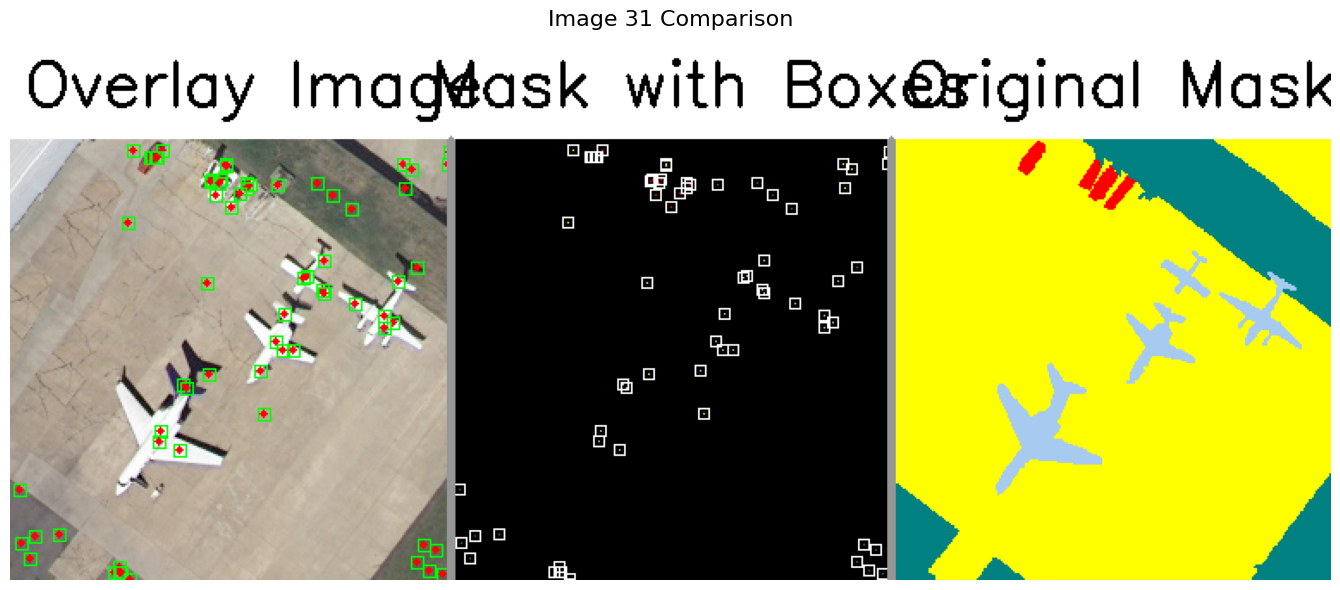

In [7]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def create_comparison_image_31(overlay_folder, boxes_folder, masks_folder, output_path, base_name="31"):
    """
    Create a horizontal composite of 3 images for image 31:
    1. Overlay image (overlay_31.png)
    2. Point mask with boxes (31.png) 
    3. Original mask (31.png)
    """
    
    # Define the specific filenames
    overlay_filename = f"overlay_{base_name}.png"
    boxes_filename = f"{base_name}.png"
    masks_filename = f"{base_name}.png"
    
    # Construct full paths
    overlay_path = os.path.join(overlay_folder, overlay_filename)
    boxes_path = os.path.join(boxes_folder, boxes_filename)
    masks_path = os.path.join(masks_folder, masks_filename)
    
    print(f"📁 Looking for files:")
    print(f"   Overlay: {overlay_path}")
    print(f"   Boxes: {boxes_path}")
    print(f"   Mask: {masks_path}")
    
    # Check if all files exist
    if not os.path.exists(overlay_path):
        print(f"❌ Overlay file not found: {overlay_path}")
        return
    if not os.path.exists(boxes_path):
        print(f"❌ Boxes file not found: {boxes_path}")
        return
    if not os.path.exists(masks_path):
        print(f"❌ Mask file not found: {masks_path}")
        return
    
    try:
        # Read all three images
        overlay_img = cv2.imread(overlay_path)
        boxes_img = cv2.imread(boxes_path)
        mask_img = cv2.imread(masks_path)
        
        if overlay_img is None:
            print("❌ Error reading overlay image")
            return
        if boxes_img is None:
            print("❌ Error reading boxes image")
            return
        if mask_img is None:
            print("❌ Error reading mask image")
            return
        
        print(f"✅ Successfully loaded all images:")
        print(f"   Overlay shape: {overlay_img.shape}")
        print(f"   Boxes shape: {boxes_img.shape}")
        print(f"   Mask shape: {mask_img.shape}")
        
        # Convert BGR to RGB for display
        overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
        boxes_rgb = cv2.cvtColor(boxes_img, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB)
        
        # Resize images to have the same height (maintain aspect ratio)
        target_height = min(overlay_rgb.shape[0], boxes_rgb.shape[0], mask_rgb.shape[0])
        
        def resize_to_height(img, height):
            h, w = img.shape[:2]
            scale = height / h
            new_w = int(w * scale)
            return cv2.resize(img, (new_w, height))
        
        overlay_resized = resize_to_height(overlay_rgb, target_height)
        boxes_resized = resize_to_height(boxes_rgb, target_height)
        mask_resized = resize_to_height(mask_rgb, target_height)
        
        # Combine images horizontally
        composite = np.hstack([overlay_resized, boxes_resized, mask_resized])
        
        # Add labels to the composite image
        label_height = 50
        composite_with_labels = np.ones((composite.shape[0] + label_height, composite.shape[1], 3), dtype=np.uint8) * 255
        
        # Place the composite image
        composite_with_labels[label_height:, :] = composite
        
        # Add text labels
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 2
        color = (0, 0, 0)  # Black text
        
        # Calculate label positions
        w1 = overlay_resized.shape[1]
        w2 = boxes_resized.shape[1]
        w3 = mask_resized.shape[1]
        
        # Center the text under each image
        cv2.putText(composite_with_labels, "Overlay Image", (w1//2 - 120, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Mask with Boxes", (w1 + w2//2 - 140, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Original Mask", (w1 + w2 + w3//2 - 120, 30), font, font_scale, color, thickness)
        
        # Add separator lines
        line_color = (150, 150, 150)
        cv2.line(composite_with_labels, (w1, label_height), (w1, composite_with_labels.shape[0]), line_color, 3)
        cv2.line(composite_with_labels, (w1 + w2, label_height), (w1 + w2, composite_with_labels.shape[0]), line_color, 3)
        
        # Save the composite image
        cv2.imwrite(output_path, cv2.cvtColor(composite_with_labels, cv2.COLOR_RGB2BGR))
        print(f"✅ Composite image saved: {output_path}")
        
        # Display the image
        plt.figure(figsize=(18, 6))
        plt.imshow(composite_with_labels)
        plt.axis('off')
        plt.title(f'Image {base_name} Comparison', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error creating composite: {str(e)}")
        import traceback
        traceback.print_exc()

def check_all_files_exist(overlay_folder, boxes_folder, masks_folder, base_name="31"):
    """
    Check if all required files exist
    """
    overlay_path = os.path.join(overlay_folder, f"overlay_{base_name}.png")
    boxes_path = os.path.join(boxes_folder, f"{base_name}.png")
    masks_path = os.path.join(masks_folder, f"{base_name}.png")
    
    print("🔍 Checking if all files exist:")
    print(f"   Overlay: {overlay_path} - {'✅ EXISTS' if os.path.exists(overlay_path) else '❌ MISSING'}")
    print(f"   Boxes: {boxes_path} - {'✅ EXISTS' if os.path.exists(boxes_path) else '❌ MISSING'}")
    print(f"   Mask: {masks_path} - {'✅ EXISTS' if os.path.exists(masks_path) else '❌ MISSING'}")
    
    return all([os.path.exists(overlay_path), os.path.exists(boxes_path), os.path.exists(masks_path)])

# Usage
if __name__ == "__main__":
    # Define your folder paths
    overlay_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images"  # Contains overlay_31.png
    boxes_folder ="/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg_withbox"  # Contains 31.png (with bounding boxes)
    masks_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks"  # Contains 31.png (original mask)
    
    # Output path for the composite image
    output_path = "image_31_comparison.png"
    
    # First, check if all files exist
    if check_all_files_exist(overlay_folder, boxes_folder, masks_folder, base_name="31"):
        print("\n🎯 All files found! Creating composite image...")
        # Create the composite image
        create_comparison_image_31(
            overlay_folder=overlay_folder,
            boxes_folder=boxes_folder, 
            masks_folder=masks_folder,
            output_path=output_path,
            base_name="31"
        )
    else:
        print("\n❌ Some files are missing. Please check the paths above.")

🔍 Checking if all files exist:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images/overlay_31.png - ✅ EXISTS
   Boxes: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg/31.png - ✅ EXISTS
   Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png - ✅ EXISTS

🎯 All files found! Creating composite image...
📁 Looking for files:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images/overlay_31.png
   Boxes: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg/31.png
   Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png
✅ Successfully loaded all images:
   Overlay shape: (256, 256, 3)
   Boxes shape: (256, 256, 3)
   Mask shape: (256, 256, 3)
✅ Composite image saved: image_31_comparison.png


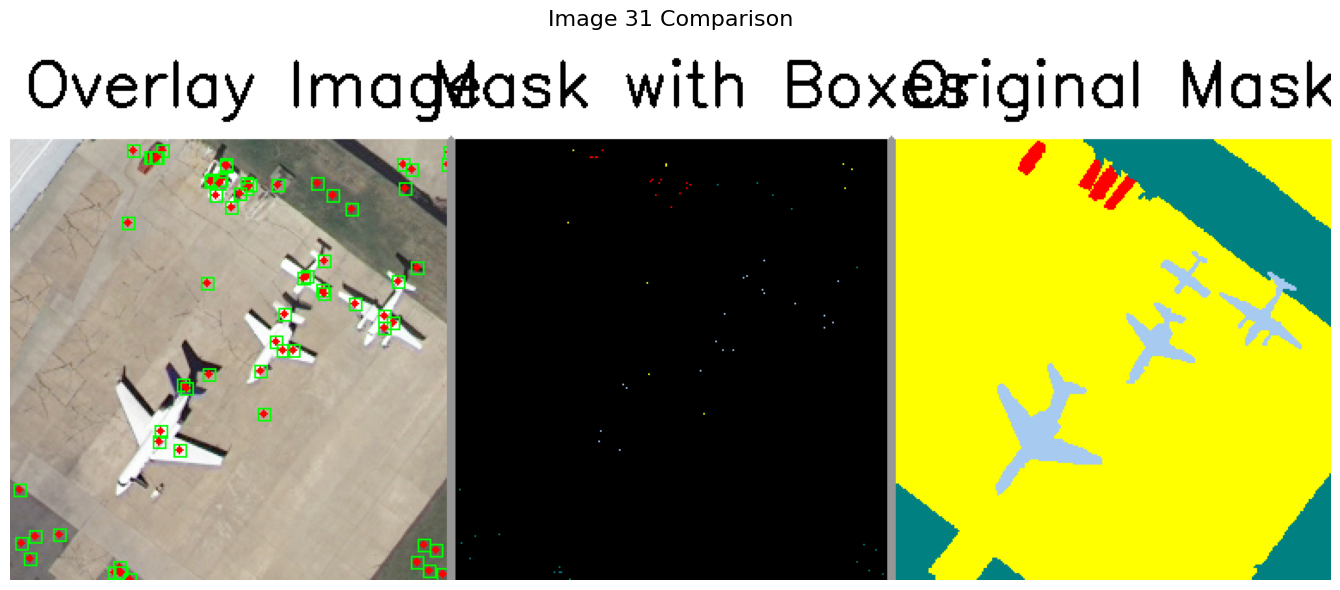

In [8]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def create_comparison_image_31(overlay_folder, boxes_folder, masks_folder, output_path, base_name="31"):
    """
    Create a horizontal composite of 3 images for image 31:
    1. Overlay image (overlay_31.png)
    2. Point mask with boxes (31.png) 
    3. Original mask (31.png)
    """
    
    # Define the specific filenames
    overlay_filename = f"overlay_{base_name}.png"
    boxes_filename = f"{base_name}.png"
    masks_filename = f"{base_name}.png"
    
    # Construct full paths
    overlay_path = os.path.join(overlay_folder, overlay_filename)
    boxes_path = os.path.join(boxes_folder, boxes_filename)
    masks_path = os.path.join(masks_folder, masks_filename)
    
    print(f"📁 Looking for files:")
    print(f"   Overlay: {overlay_path}")
    print(f"   Boxes: {boxes_path}")
    print(f"   Mask: {masks_path}")
    
    # Check if all files exist
    if not os.path.exists(overlay_path):
        print(f"❌ Overlay file not found: {overlay_path}")
        return
    if not os.path.exists(boxes_path):
        print(f"❌ Boxes file not found: {boxes_path}")
        return
    if not os.path.exists(masks_path):
        print(f"❌ Mask file not found: {masks_path}")
        return
    
    try:
        # Read all three images
        overlay_img = cv2.imread(overlay_path)
        boxes_img = cv2.imread(boxes_path)
        mask_img = cv2.imread(masks_path)
        
        if overlay_img is None:
            print("❌ Error reading overlay image")
            return
        if boxes_img is None:
            print("❌ Error reading boxes image")
            return
        if mask_img is None:
            print("❌ Error reading mask image")
            return
        
        print(f"✅ Successfully loaded all images:")
        print(f"   Overlay shape: {overlay_img.shape}")
        print(f"   Boxes shape: {boxes_img.shape}")
        print(f"   Mask shape: {mask_img.shape}")
        
        # Convert BGR to RGB for display
        overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
        boxes_rgb = cv2.cvtColor(boxes_img, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.cvtColor(mask_img, cv2.COLOR_BGR2RGB)
        
        # Resize images to have the same height (maintain aspect ratio)
        target_height = min(overlay_rgb.shape[0], boxes_rgb.shape[0], mask_rgb.shape[0])
        
        def resize_to_height(img, height):
            h, w = img.shape[:2]
            scale = height / h
            new_w = int(w * scale)
            return cv2.resize(img, (new_w, height))
        
        overlay_resized = resize_to_height(overlay_rgb, target_height)
        boxes_resized = resize_to_height(boxes_rgb, target_height)
        mask_resized = resize_to_height(mask_rgb, target_height)
        
        # Combine images horizontally
        composite = np.hstack([overlay_resized, boxes_resized, mask_resized])
        
        # Add labels to the composite image
        label_height = 50
        composite_with_labels = np.ones((composite.shape[0] + label_height, composite.shape[1], 3), dtype=np.uint8) * 255
        
        # Place the composite image
        composite_with_labels[label_height:, :] = composite
        
        # Add text labels
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 2
        color = (0, 0, 0)  # Black text
        
        # Calculate label positions
        w1 = overlay_resized.shape[1]
        w2 = boxes_resized.shape[1]
        w3 = mask_resized.shape[1]
        
        # Center the text under each image
        cv2.putText(composite_with_labels, "Overlay Image", (w1//2 - 120, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Mask with Boxes", (w1 + w2//2 - 140, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Original Mask", (w1 + w2 + w3//2 - 120, 30), font, font_scale, color, thickness)
        
        # Add separator lines
        line_color = (150, 150, 150)
        cv2.line(composite_with_labels, (w1, label_height), (w1, composite_with_labels.shape[0]), line_color, 3)
        cv2.line(composite_with_labels, (w1 + w2, label_height), (w1 + w2, composite_with_labels.shape[0]), line_color, 3)
        
        # Save the composite image
        cv2.imwrite(output_path, cv2.cvtColor(composite_with_labels, cv2.COLOR_RGB2BGR))
        print(f"✅ Composite image saved: {output_path}")
        
        # Display the image
        plt.figure(figsize=(18, 6))
        plt.imshow(composite_with_labels)
        plt.axis('off')
        plt.title(f'Image {base_name} Comparison', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error creating composite: {str(e)}")
        import traceback
        traceback.print_exc()

def check_all_files_exist(overlay_folder, boxes_folder, masks_folder, base_name="31"):
    """
    Check if all required files exist
    """
    overlay_path = os.path.join(overlay_folder, f"overlay_{base_name}.png")
    boxes_path = os.path.join(boxes_folder, f"{base_name}.png")
    masks_path = os.path.join(masks_folder, f"{base_name}.png")
    
    print("🔍 Checking if all files exist:")
    print(f"   Overlay: {overlay_path} - {'✅ EXISTS' if os.path.exists(overlay_path) else '❌ MISSING'}")
    print(f"   Boxes: {boxes_path} - {'✅ EXISTS' if os.path.exists(boxes_path) else '❌ MISSING'}")
    print(f"   Mask: {masks_path} - {'✅ EXISTS' if os.path.exists(masks_path) else '❌ MISSING'}")
    
    return all([os.path.exists(overlay_path), os.path.exists(boxes_path), os.path.exists(masks_path)])

# Usage
if __name__ == "__main__":
    # Define your folder paths
    overlay_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_overlay_train_images"  # Contains overlay_31.png
    boxes_folder ="/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg"  # Contains 31.png (with bounding boxes)
    masks_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks"  # Contains 31.png (original mask)
    
    # Output path for the composite image
    output_path = "image_31_comparison.png"
    
    # First, check if all files exist
    if check_all_files_exist(overlay_folder, boxes_folder, masks_folder, base_name="31"):
        print("\n🎯 All files found! Creating composite image...")
        # Create the composite image
        create_comparison_image_31(
            overlay_folder=overlay_folder,
            boxes_folder=boxes_folder, 
            masks_folder=masks_folder,
            output_path=output_path,
            base_name="31"
        )
    else:
        print("\n❌ Some files are missing. Please check the paths above.")

In [9]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_white_with_boundary(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, boundary_thickness=2):
    """
    Change mask background to white and add black boundary around the mask
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
        boundary_thickness: Thickness of the black boundary around the mask
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to WHITE (255,255,255) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]  # White
                
                # Create black boundary around the entire mask
                # First, find the non-background region (the actual mask content)
                non_bg_mask = ~background_mask
                
                if np.any(non_bg_mask):  # Only add boundary if there's mask content
                    # Find the bounding box of the mask content
                    rows = np.any(non_bg_mask, axis=1)
                    cols = np.any(non_bg_mask, axis=0)
                    
                    if np.any(rows) and np.any(cols):
                        y_min, y_max = np.where(rows)[0][[0, -1]]
                        x_min, x_max = np.where(cols)[0][[0, -1]]
                        
                        # Add black boundary around the mask content
                        # Top boundary
                        top_boundary = max(0, y_min - boundary_thickness)
                        result_array[top_boundary:y_min, x_min:x_max+1] = [0, 0, 0]
                        
                        # Bottom boundary
                        bottom_boundary = min(result_array.shape[0], y_max + boundary_thickness + 1)
                        result_array[y_max+1:bottom_boundary, x_min:x_max+1] = [0, 0, 0]
                        
                        # Left boundary
                        left_boundary = max(0, x_min - boundary_thickness)
                        result_array[y_min:y_max+1, left_boundary:x_min] = [0, 0, 0]
                        
                        # Right boundary
                        right_boundary = min(result_array.shape[1], x_max + boundary_thickness + 1)
                        result_array[y_min:y_max+1, x_max+1:right_boundary] = [0, 0, 0]
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename}")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Processed masks with white background and black boundary saved to: {output_folder}")

def change_mask_background_to_white_with_outline(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, outline_thickness=2):
    """
    Alternative version: Adds black outline around each mask region using edge detection
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            with Image.open(input_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to white
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]
                
                # Create black outline around mask regions
                non_bg_mask = ~background_mask
                
                if np.any(non_bg_mask):
                    # Create outline by dilating the mask and subtracting the original
                    from scipy import ndimage
                    
                    # Dilate the non-background mask
                    structure = np.ones((outline_thickness*2+1, outline_thickness*2+1))
                    dilated_mask = ndimage.binary_dilation(non_bg_mask, structure=structure)
                    
                    # Outline is the dilated mask minus the original mask
                    outline_mask = dilated_mask & ~non_bg_mask
                    
                    # Apply black color to outline
                    result_array[outline_mask] = [0, 0, 0]
                
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed with outline: {filename}")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with white background and black outline saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1"
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_boundary"
    
    # Method 1: White background with rectangular black boundary
    change_mask_background_to_white_with_boundary(
        input_folder=input_folder,
        output_folder=output_folder,
        background_color=(100, 100, 100),
        tolerance=0,
        boundary_thickness=2  # Adjust thickness as needed
    )
    
    # Method 2: White background with outline around mask shapes (requires scipy)
    # Uncomment if you want to try the outline method instead
    # change_mask_background_to_white_with_outline(
    #     input_folder=input_folder,
    #     output_folder=output_folder + "_outline",
    #     background_color=(100, 100, 100),
    #     tolerance=0,
    #     outline_thickness=2
    # )

Found 630 images to process
✓ Processed: 251.png
✓ Processed: 542.png
✓ Processed: 8.png
✓ Processed: 233.png
✓ Processed: 611.png
✓ Processed: 302.png
✓ Processed: 73.png
✓ Processed: 424.png
✓ Processed: 103.png
✓ Processed: 247.png
✓ Processed: 180.png
✓ Processed: 583.png
✓ Processed: 264.png
✓ Processed: 606.png
✓ Processed: 6.png
✓ Processed: 421.png
✓ Processed: 130.png
✓ Processed: 228.png
✓ Processed: 450.png
✓ Processed: 96.png
✓ Processed: 236.png
✓ Processed: 33.png
✓ Processed: 609.png
✓ Processed: 11.png
✓ Processed: 275.png
✓ Processed: 591.png
✓ Processed: 54.png
✓ Processed: 528.png
✓ Processed: 182.png
✓ Processed: 32.png
✓ Processed: 570.png
✓ Processed: 299.png
✓ Processed: 430.png
✓ Processed: 575.png
✓ Processed: 480.png
✓ Processed: 473.png
✓ Processed: 131.png
✓ Processed: 262.png
✓ Processed: 47.png
✓ Processed: 344.png
✓ Processed: 574.png
✓ Processed: 486.png
✓ Processed: 51.png
✓ Processed: 311.png
✓ Processed: 621.png
✓ Processed: 628.png
✓ Processed: 250.p

In [1]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_white_with_border(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3):
    """
    Change mask background to white and add black border around the entire image
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
        border_thickness: Thickness of the black border around the entire image
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to WHITE (255,255,255) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]  # White
                
                # Add black border around the ENTIRE image
                height, width = result_array.shape[:2]
                
                # Top border
                result_array[0:border_thickness, :] = [0, 0, 0]
                # Bottom border
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                # Left border
                result_array[:, 0:border_thickness] = [0, 0, 0]
                # Right border
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename}")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Processed masks with white background and black border saved to: {output_folder}")

def change_mask_background_to_white_with_thick_border(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=5):
    """
    Version with thicker border for better visibility
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            with Image.open(input_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to white
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]
                
                # Add thick black border around entire image
                height, width = result_array.shape[:2]
                
                # Top border
                result_array[0:border_thickness, :] = [0, 0, 0]
                # Bottom border
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                # Left border
                result_array[:, 0:border_thickness] = [0, 0, 0]
                # Right border
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed with thick border: {filename}")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with white background and thick black border saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1"
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border"
    
    # Method 1: Regular border
    change_mask_background_to_white_with_border(
        input_folder=input_folder,
        output_folder=output_folder,
        background_color=(100, 100, 100),
        tolerance=0,
        border_thickness=3  # 3-pixel thick black border
    )
    
    # Method 2: Thicker border (uncomment if needed)
    # change_mask_background_to_white_with_thick_border(
    #     input_folder=input_folder,
    #     output_folder=output_folder + "_thick",
    #     background_color=(100, 100, 100),
    #     tolerance=0,
    #     border_thickness=5  # 5-pixel thick black border
    # )

Found 630 images to process
✓ Processed: 251.png
✓ Processed: 542.png
✓ Processed: 8.png
✓ Processed: 233.png
✓ Processed: 611.png
✓ Processed: 302.png
✓ Processed: 73.png
✓ Processed: 424.png
✓ Processed: 103.png
✓ Processed: 247.png
✓ Processed: 180.png
✓ Processed: 583.png
✓ Processed: 264.png
✓ Processed: 606.png
✓ Processed: 6.png
✓ Processed: 421.png
✓ Processed: 130.png
✓ Processed: 228.png
✓ Processed: 450.png
✓ Processed: 96.png
✓ Processed: 236.png
✓ Processed: 33.png
✓ Processed: 609.png
✓ Processed: 11.png
✓ Processed: 275.png
✓ Processed: 591.png
✓ Processed: 54.png
✓ Processed: 528.png
✓ Processed: 182.png
✓ Processed: 32.png
✓ Processed: 570.png
✓ Processed: 299.png
✓ Processed: 430.png
✓ Processed: 575.png
✓ Processed: 480.png
✓ Processed: 473.png
✓ Processed: 131.png
✓ Processed: 262.png
✓ Processed: 47.png
✓ Processed: 344.png
✓ Processed: 574.png
✓ Processed: 486.png
✓ Processed: 51.png
✓ Processed: 311.png
✓ Processed: 621.png
✓ Processed: 628.png
✓ Processed: 250.p

In [2]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_white_with_border_and_boxes(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3):
    """
    Change mask background to white, add black border around entire image, 
    and small bounding boxes around each point
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
        border_thickness: Thickness of the black border around the entire image
        box_size: Size of the bounding boxes around each point
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to WHITE (255,255,255) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]  # White
                
                # Find non-background points (the actual points we want to put boxes around)
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # Draw small bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    # Calculate box coordinates
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box (black rectangle edges)
                    result_array[y1:y2, x1] = box_color        # Left edge
                    result_array[y1:y2, x2-1] = box_color      # Right edge
                    result_array[y1, x1:x2] = box_color        # Top edge
                    result_array[y2-1, x1:x2] = box_color      # Bottom edge
                
                # Add black border around the ENTIRE image
                height, width = result_array.shape[:2]
                
                # Top border
                result_array[0:border_thickness, :] = [0, 0, 0]
                # Bottom border
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                # Left border
                result_array[:, 0:border_thickness] = [0, 0, 0]
                # Right border
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename} - {len(y_coords)} points with boxes")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with white background, black border, and point boxes saved to: {output_folder}")

def change_mask_background_to_white_with_border_and_filled_boxes(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=4):
    """
    Alternative version: Uses filled boxes instead of just edges
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            with Image.open(input_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to white
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]
                
                # Find non-background points
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # Draw filled bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    # Calculate box coordinates
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw filled box
                    result_array[y1:y2, x1:x2] = box_color
                
                # Add black border around entire image
                height, width = result_array.shape[:2]
                result_array[0:border_thickness, :] = [0, 0, 0]
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                result_array[:, 0:border_thickness] = [0, 0, 0]
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed with filled boxes: {filename} - {len(y_coords)} points")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with filled boxes saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1"
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes"
    
    # Method 1: Black border + box edges around points
    change_mask_background_to_white_with_border_and_boxes(
        input_folder=input_folder,
        output_folder=output_folder,
        background_color=(100, 100, 100),
        tolerance=0,
        border_thickness=2,  # Thickness of outer border
        box_size=3          # Size of boxes around points
    )
    
    # Method 2: Black border + filled boxes around points
    # change_mask_background_to_white_with_border_and_filled_boxes(
    #     input_folder=input_folder,
    #     output_folder=output_folder + "_filled",
    #     background_color=(100, 100, 100),
    #     tolerance=0,
    #     border_thickness=3,
    #     box_size=4
    # )

Found 630 images to process
✓ Processed: 251.png - 120 points with boxes
✓ Processed: 542.png - 80 points with boxes
✓ Processed: 8.png - 5 points with boxes
✓ Processed: 233.png - 5 points with boxes
✓ Processed: 611.png - 25 points with boxes
✓ Processed: 302.png - 105 points with boxes
✓ Processed: 73.png - 60 points with boxes
✓ Processed: 424.png - 200 points with boxes
✓ Processed: 103.png - 10 points with boxes
✓ Processed: 247.png - 100 points with boxes
✓ Processed: 180.png - 594 points with boxes
✓ Processed: 583.png - 20 points with boxes
✓ Processed: 264.png - 45 points with boxes
✓ Processed: 606.png - 120 points with boxes
✓ Processed: 6.png - 5 points with boxes
✓ Processed: 421.png - 55 points with boxes
✓ Processed: 130.png - 70 points with boxes
✓ Processed: 228.png - 5 points with boxes
✓ Processed: 450.png - 100 points with boxes
✓ Processed: 96.png - 10 points with boxes
✓ Processed: 236.png - 5 points with boxes
✓ Processed: 33.png - 15 points with boxes
✓ Process

In [3]:
import os
import cv2
import numpy as np
from PIL import Image

def overlay_points_with_original_colors_and_boxes(mask_folder, image_folder, output_folder, 
                                                 background_color=(0, 0, 0), 
                                                 box_size=3, box_color=(0, 255, 0), tolerance=0):
    """
    Overlay points with their original colors from mask + green bounding boxes
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    mask_files = [f for f in os.listdir(mask_folder) 
                  if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(mask_files)} mask files to process")
    
    for mask_filename in mask_files:
        mask_path = os.path.join(mask_folder, mask_filename)
        
        # Find corresponding image
        image_filename = None
        base_name = os.path.splitext(mask_filename)[0]
        for ext in valid_extensions:
            image_path = os.path.join(image_folder, base_name + ext)
            if os.path.exists(image_path):
                image_filename = base_name + ext
                break
        
        if not image_filename:
            print(f"✗ No corresponding image found for mask: {mask_filename}")
            continue
        
        image_path = os.path.join(image_folder, image_filename)
        output_path = os.path.join(output_folder, f"overlay_{mask_filename}")
        
        try:
            # Read images
            mask = cv2.imread(mask_path)
            original_image = cv2.imread(image_path)
            
            if mask is None or original_image is None:
                continue
            
            # Convert to RGB for processing
            mask_rgb = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
            original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
            
            # Identify BACKGROUND pixels (to ignore)
            if tolerance == 0:
                background_mask = ((mask_rgb[:,:,0] == background_color[0]) & 
                                  (mask_rgb[:,:,1] == background_color[1]) & 
                                  (mask_rgb[:,:,2] == background_color[2]))
            else:
                color_diff = np.abs(mask_rgb - np.array(background_color))
                background_mask = np.all(color_diff <= tolerance, axis=2)
            
            # NON-BACKGROUND = points we want to mark
            non_bg_mask = ~background_mask
            y_coords, x_coords = np.where(non_bg_mask)
            
            # Start with original image
            overlay_img = original_rgb.copy()
            
            # Draw boxes and copy original point colors
            for y, x in zip(y_coords, x_coords):
                # Get original point color from mask
                original_point_color = mask_rgb[y, x]
                
                # Calculate box coordinates
                y1 = max(0, y - box_size)
                y2 = min(overlay_img.shape[0], y + box_size + 1)
                x1 = max(0, x - box_size)
                x2 = min(overlay_img.shape[1], x + box_size + 1)
                
                # Draw green bounding box
                cv2.rectangle(overlay_img, (x1, y1), (x2, y2), box_color, 1)
                
                # Draw point with original color (slightly enhanced for visibility)
                cv2.circle(overlay_img, (x, y), 2, [int(c) for c in original_point_color], -1)
            
            # Convert back to BGR and save
            overlay_bgr = cv2.cvtColor(overlay_img, cv2.COLOR_RGB2BGR)
            cv2.imwrite(output_path, overlay_bgr)
            print(f"✓ Overlay: {mask_filename} - {len(y_coords)} points")
            
        except Exception as e:
            print(f"✗ Error: {mask_filename} - {str(e)}")
    
    print(f"✅ Overlay images with original colors + boxes saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_blackbg" 
    image_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images" 
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images" 
    
    print("=== CREATING OVERLAYS WITH ORIGINAL COLORS + BOXES ===")
    overlay_points_with_original_colors_and_boxes(
        mask_folder=mask_folder,
        image_folder=image_folder,
        output_folder=output_folder,
        background_color=(0, 0, 0),  # Black background to ignore
        box_size=3,                  # Small boxes around points
        box_color=(0, 255, 0),       # Green boxes
        tolerance=0                  # Exact background match
    )

=== CREATING OVERLAYS WITH ORIGINAL COLORS + BOXES ===
Found 630 mask files to process
✓ Overlay: 251.png - 120 points
✓ Overlay: 542.png - 80 points
✓ Overlay: 8.png - 5 points
✓ Overlay: 233.png - 5 points
✓ Overlay: 611.png - 25 points
✓ Overlay: 302.png - 105 points
✓ Overlay: 73.png - 60 points
✓ Overlay: 424.png - 200 points
✓ Overlay: 103.png - 10 points
✓ Overlay: 247.png - 100 points
✓ Overlay: 180.png - 594 points
✓ Overlay: 583.png - 20 points
✓ Overlay: 264.png - 45 points
✓ Overlay: 606.png - 120 points
✓ Overlay: 6.png - 5 points
✓ Overlay: 421.png - 55 points
✓ Overlay: 130.png - 70 points
✓ Overlay: 228.png - 5 points
✓ Overlay: 450.png - 100 points
✓ Overlay: 96.png - 10 points
✓ Overlay: 236.png - 5 points
✓ Overlay: 33.png - 15 points
✓ Overlay: 609.png - 70 points
✓ Overlay: 11.png - 5 points
✓ Overlay: 275.png - 35 points
✓ Overlay: 591.png - 110 points
✓ Overlay: 54.png - 45 points
✓ Overlay: 528.png - 20 points
✓ Overlay: 182.png - 110 points
✓ Overlay: 32.png - 

In [4]:
import os
from PIL import Image
import numpy as np
import shutil

def change_mask_background_to_white_with_border_and_enhanced_points(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3, point_enhance_size=2):
    """
    Change mask background to white, add black border around entire image, 
    small bounding boxes around each point, and enhance point visibility
    
    Args:
        input_folder: Folder containing original masks
        output_folder: Folder where processed masks will be saved
        background_color: The RGB color to replace (default: 100,100,100)
        tolerance: Color tolerance for background detection (0 for exact match)
        border_thickness: Thickness of the black border around the entire image
        box_size: Size of the bounding boxes around each point
        point_enhance_size: How much to enlarge the points for better visibility
    """
    
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            # Open image
            with Image.open(input_path) as img:
                # Convert to RGB if needed
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                # Convert to numpy array
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    # Exact match
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    # With tolerance
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to WHITE (255,255,255) and keep everything else as is
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]  # White
                
                # Find non-background points (the actual points we want to put boxes around)
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # First, enhance the points by making them larger
                enhanced_points = np.zeros_like(result_array)
                for y, x in zip(y_coords, x_coords):
                    # Get original point color
                    point_color = result_array[y, x]
                    
                    # Create enhanced point (larger circle)
                    for dy in range(-point_enhance_size, point_enhance_size + 1):
                        for dx in range(-point_enhance_size, point_enhance_size + 1):
                            ny, nx = y + dy, x + dx
                            if (0 <= ny < result_array.shape[0] and 
                                0 <= nx < result_array.shape[1] and 
                                (dx*dx + dy*dy) <= point_enhance_size*point_enhance_size):
                                enhanced_points[ny, nx] = point_color
                
                # Apply enhanced points to result
                enhanced_mask = np.any(enhanced_points != 0, axis=2)
                result_array[enhanced_mask] = enhanced_points[enhanced_mask]
                
                # Draw small bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    # Calculate box coordinates
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box (black rectangle edges)
                    result_array[y1:y2, x1] = box_color        # Left edge
                    result_array[y1:y2, x2-1] = box_color      # Right edge
                    result_array[y1, x1:x2] = box_color        # Top edge
                    result_array[y2-1, x1:x2] = box_color      # Bottom edge
                
                # Add black border around the ENTIRE image
                height, width = result_array.shape[:2]
                
                # Top border
                result_array[0:border_thickness, :] = [0, 0, 0]
                # Bottom border
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                # Left border
                result_array[:, 0:border_thickness] = [0, 0, 0]
                # Right border
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                # Convert back to PIL Image and save
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed: {filename} - {len(y_coords)} enhanced points with boxes")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Enhanced masks with white background, black border, and point boxes saved to: {output_folder}")

def change_mask_background_to_white_with_border_and_bold_points(input_folder, output_folder, background_color=(100, 100, 100), tolerance=0, border_thickness=3, box_size=3, point_boldness=2):
    """
    Alternative version: Makes points bolder and more visible
    """
    
    os.makedirs(output_folder, exist_ok=True)
    
    valid_extensions = {'.png', '.jpg', '.jpeg', '.tiff', '.bmp', '.tif'}
    image_files = [f for f in os.listdir(input_folder) 
                   if any(f.lower().endswith(ext) for ext in valid_extensions)]
    
    print(f"Found {len(image_files)} images to process")
    
    for filename in image_files:
        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)
        
        try:
            with Image.open(input_path) as img:
                if img.mode != 'RGB':
                    img = img.convert('RGB')
                
                img_array = np.array(img)
                
                # Create mask for background pixels
                if tolerance == 0:
                    background_mask = (img_array[:,:,0] == background_color[0]) & \
                                     (img_array[:,:,1] == background_color[1]) & \
                                     (img_array[:,:,2] == background_color[2])
                else:
                    color_diff = np.abs(img_array - np.array(background_color))
                    background_mask = np.all(color_diff <= tolerance, axis=2)
                
                # Change background to white
                result_array = img_array.copy()
                result_array[background_mask] = [255, 255, 255]
                
                # Find non-background points
                non_bg_mask = ~background_mask
                y_coords, x_coords = np.where(non_bg_mask)
                
                # Make points bolder by creating a dark outline around them
                for y, x in zip(y_coords, x_coords):
                    point_color = result_array[y, x]
                    
                    # Create bold point with dark outline
                    for dy in range(-point_boldness, point_boldness + 1):
                        for dx in range(-point_boldness, point_boldness + 1):
                            ny, nx = y + dy, x + dx
                            if (0 <= ny < result_array.shape[0] and 
                                0 <= nx < result_array.shape[1]):
                                # For the outer ring, use darker version of the color
                                if abs(dy) == point_boldness or abs(dx) == point_boldness:
                                    # Darker outline
                                    dark_color = [max(0, c-100) for c in point_color]
                                    result_array[ny, nx] = dark_color
                                else:
                                    # Keep original color for inner part
                                    result_array[ny, nx] = point_color
                
                # Draw bounding boxes around each point
                box_color = [0, 0, 0]  # Black boxes
                for y, x in zip(y_coords, x_coords):
                    y1 = max(0, y - box_size)
                    y2 = min(result_array.shape[0], y + box_size + 1)
                    x1 = max(0, x - box_size)
                    x2 = min(result_array.shape[1], x + box_size + 1)
                    
                    # Draw box edges
                    result_array[y1:y2, x1] = box_color
                    result_array[y1:y2, x2-1] = box_color
                    result_array[y1, x1:x2] = box_color
                    result_array[y2-1, x1:x2] = box_color
                
                # Add black border around entire image
                height, width = result_array.shape[:2]
                result_array[0:border_thickness, :] = [0, 0, 0]
                result_array[height-border_thickness:height, :] = [0, 0, 0]
                result_array[:, 0:border_thickness] = [0, 0, 0]
                result_array[:, width-border_thickness:width] = [0, 0, 0]
                
                result_img = Image.fromarray(result_array)
                result_img.save(output_path)
                
                print(f"✓ Processed with bold points: {filename} - {len(y_coords)} points")
                
        except Exception as e:
            print(f"✗ Error processing {filename}: {str(e)}")
    
    print(f"\nDone! Masks with bold points saved to: {output_folder}")

# Usage
if __name__ == "__main__":
    input_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1"
    output_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced"
    
    # Method 1: Enhanced points (larger and more visible)
    change_mask_background_to_white_with_border_and_enhanced_points(
        input_folder=input_folder,
        output_folder=output_folder,
        background_color=(100, 100, 100),
        tolerance=0,
        border_thickness=3,
        box_size=3,
        point_enhance_size=2  # Makes points 2 pixels larger in radius
    )
    
    # Method 2: Bold points with dark outline
    # change_mask_background_to_white_with_border_and_bold_points(
    #     input_folder=input_folder,
    #     output_folder=output_folder + "_bold",
    #     background_color=(100, 100, 100),
    #     tolerance=0,
    #     border_thickness=3,
    #     box_size=3,
    #     point_boldness=2  # Adds dark outline around points
    # )

Found 630 images to process
✓ Processed: 251.png - 120 enhanced points with boxes
✓ Processed: 542.png - 80 enhanced points with boxes
✓ Processed: 8.png - 5 enhanced points with boxes
✓ Processed: 233.png - 5 enhanced points with boxes
✓ Processed: 611.png - 25 enhanced points with boxes
✓ Processed: 302.png - 105 enhanced points with boxes
✓ Processed: 73.png - 60 enhanced points with boxes
✓ Processed: 424.png - 200 enhanced points with boxes
✓ Processed: 103.png - 10 enhanced points with boxes
✓ Processed: 247.png - 100 enhanced points with boxes
✓ Processed: 180.png - 594 enhanced points with boxes
✓ Processed: 583.png - 20 enhanced points with boxes
✓ Processed: 264.png - 45 enhanced points with boxes
✓ Processed: 606.png - 120 enhanced points with boxes
✓ Processed: 6.png - 5 enhanced points with boxes
✓ Processed: 421.png - 55 enhanced points with boxes
✓ Processed: 130.png - 70 enhanced points with boxes
✓ Processed: 228.png - 5 enhanced points with boxes
✓ Processed: 450.png 

🔍 Checking if all files exist:
   Overlay (overlay_31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images/overlay_31.png - ✅ EXISTS
   WhiteBG (31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced/31.png - ✅ EXISTS
   Orig Mask (31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png - ✅ EXISTS

🎯 All files found! Creating composite image...
📁 Looking for files:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images/overlay_31.png
   WhiteBG: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced/31.png
   Orig Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png
✅ Successfully loaded all images:
   Overlay shape: (256, 256, 3)
   WhiteBG shape: (256, 256, 3)
   Orig Mask shape: (256, 256, 3)
✅ Composite image saved: image_31_comparison.png


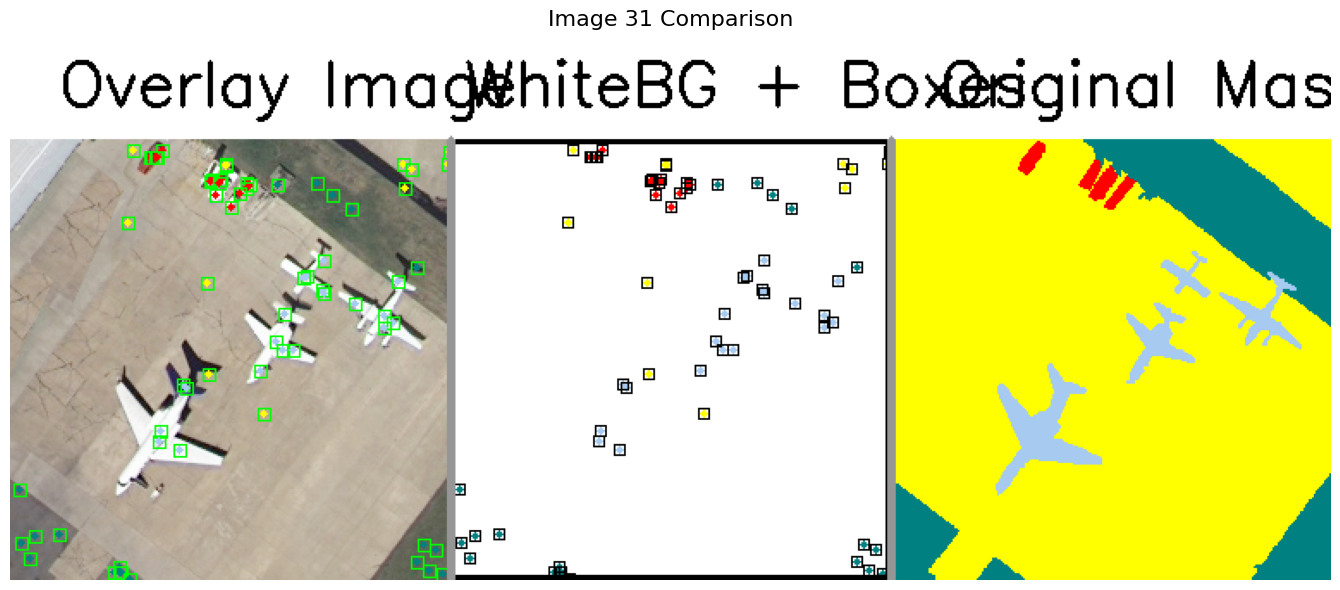

In [5]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def create_comparison_image_31(overlay_folder, whitebg_folder, orig_mask_folder, output_path, base_name="31"):
    """
    Create a horizontal composite of 3 images for image 31:
    1. Overlay image (overlay_31.png)
    2. Point mask with white background (31.png)
    3. Original mask (31.png)
    """
    
    # Define the specific filenames with different naming patterns
    overlay_filename = f"overlay_{base_name}.png"  # overlay_31.png
    whitebg_filename = f"{base_name}.png"          # 31.png
    orig_mask_filename = f"{base_name}.png"        # 31.png
    
    # Construct full paths
    overlay_path = os.path.join(overlay_folder, overlay_filename)
    whitebg_path = os.path.join(whitebg_folder, whitebg_filename)
    orig_mask_path = os.path.join(orig_mask_folder, orig_mask_filename)
    
    print(f"📁 Looking for files:")
    print(f"   Overlay: {overlay_path}")
    print(f"   WhiteBG: {whitebg_path}")
    print(f"   Orig Mask: {orig_mask_path}")
    
    # Check if all files exist
    if not os.path.exists(overlay_path):
        print(f"❌ Overlay file not found: {overlay_path}")
        return
    if not os.path.exists(whitebg_path):
        print(f"❌ WhiteBG file not found: {whitebg_path}")
        return
    if not os.path.exists(orig_mask_path):
        print(f"❌ Original mask file not found: {orig_mask_path}")
        return
    
    try:
        # Read all three images
        overlay_img = cv2.imread(overlay_path)
        whitebg_img = cv2.imread(whitebg_path)
        orig_mask_img = cv2.imread(orig_mask_path)
        
        if overlay_img is None:
            print("❌ Error reading overlay image")
            return
        if whitebg_img is None:
            print("❌ Error reading whitebg image")
            return
        if orig_mask_img is None:
            print("❌ Error reading original mask image")
            return
        
        print(f"✅ Successfully loaded all images:")
        print(f"   Overlay shape: {overlay_img.shape}")
        print(f"   WhiteBG shape: {whitebg_img.shape}")
        print(f"   Orig Mask shape: {orig_mask_img.shape}")
        
        # Convert BGR to RGB for display
        overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
        whitebg_rgb = cv2.cvtColor(whitebg_img, cv2.COLOR_BGR2RGB)
        orig_mask_rgb = cv2.cvtColor(orig_mask_img, cv2.COLOR_BGR2RGB)
        
        # Resize images to have the same height (maintain aspect ratio)
        target_height = min(overlay_rgb.shape[0], whitebg_rgb.shape[0], orig_mask_rgb.shape[0])
        
        def resize_to_height(img, height):
            h, w = img.shape[:2]
            scale = height / h
            new_w = int(w * scale)
            return cv2.resize(img, (new_w, height))
        
        overlay_resized = resize_to_height(overlay_rgb, target_height)
        whitebg_resized = resize_to_height(whitebg_rgb, target_height)
        orig_mask_resized = resize_to_height(orig_mask_rgb, target_height)
        
        # Combine images horizontally
        composite = np.hstack([overlay_resized, whitebg_resized, orig_mask_resized])
        
        # Add labels to the composite image
        label_height = 50
        composite_with_labels = np.ones((composite.shape[0] + label_height, composite.shape[1], 3), dtype=np.uint8) * 255
        
        # Place the composite image
        composite_with_labels[label_height:, :] = composite
        
        # Add text labels
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 2
        color = (0, 0, 0)  # Black text
        
        # Calculate label positions
        w1 = overlay_resized.shape[1]
        w2 = whitebg_resized.shape[1]
        w3 = orig_mask_resized.shape[1]
        
        # Center the text under each image
        cv2.putText(composite_with_labels, "Overlay Image", (w1//2 - 100, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "WhiteBG + Boxes", (w1 + w2//2 - 120, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Original Mask", (w1 + w2 + w3//2 - 100, 30), font, font_scale, color, thickness)
        
        # Add separator lines
        line_color = (150, 150, 150)
        cv2.line(composite_with_labels, (w1, label_height), (w1, composite_with_labels.shape[0]), line_color, 3)
        cv2.line(composite_with_labels, (w1 + w2, label_height), (w1 + w2, composite_with_labels.shape[0]), line_color, 3)
        
        # Save the composite image
        cv2.imwrite(output_path, cv2.cvtColor(composite_with_labels, cv2.COLOR_RGB2BGR))
        print(f"✅ Composite image saved: {output_path}")
        
        # Display the image
        plt.figure(figsize=(18, 6))
        plt.imshow(composite_with_labels)
        plt.axis('off')
        plt.title(f'Image {base_name} Comparison', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error creating composite: {str(e)}")
        import traceback
        traceback.print_exc()

def check_all_files_exist(overlay_folder, whitebg_folder, orig_mask_folder, base_name="31"):
    """
    Check if all required files exist with correct naming patterns
    """
    overlay_path = os.path.join(overlay_folder, f"overlay_{base_name}.png")  # overlay_31.png
    whitebg_path = os.path.join(whitebg_folder, f"{base_name}.png")          # 31.png
    orig_mask_path = os.path.join(orig_mask_folder, f"{base_name}.png")      # 31.png
    
    print("🔍 Checking if all files exist:")
    print(f"   Overlay (overlay_{base_name}.png): {overlay_path} - {'✅ EXISTS' if os.path.exists(overlay_path) else '❌ MISSING'}")
    print(f"   WhiteBG ({base_name}.png): {whitebg_path} - {'✅ EXISTS' if os.path.exists(whitebg_path) else '❌ MISSING'}")
    print(f"   Orig Mask ({base_name}.png): {orig_mask_path} - {'✅ EXISTS' if os.path.exists(orig_mask_path) else '❌ MISSING'}")
    
    return all([os.path.exists(overlay_path), os.path.exists(whitebg_path), os.path.exists(orig_mask_path)])

# Usage
if __name__ == "__main__":
    # Define your folder paths
    overlay_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images"  # Contains overlay_31.png
    whitebg_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced"  # Contains 31.png (white background + boxes)
    orig_mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks"  # Contains 31.png (original mask)
    
    # Output path for the composite image
    output_path = "image_31_comparison.png"
    
    # First, check if all files exist
    if check_all_files_exist(overlay_folder, whitebg_folder, orig_mask_folder, base_name="31"):
        print("\n🎯 All files found! Creating composite image...")
        # Create the composite image
        create_comparison_image_31(
            overlay_folder=overlay_folder,
            whitebg_folder=whitebg_folder, 
            orig_mask_folder=orig_mask_folder,
            output_path=output_path,
            base_name="31"
        )
    else:
        print("\n❌ Some files are missing. Please check the paths above.")
        
        # Let's see what files actually exist in each folder
        print("\n📂 Actual files in folders:")
        print(f"Overlay folder files containing '31': {[f for f in os.listdir(overlay_folder) if '31' in f]}")
        print(f"WhiteBG folder files containing '31': {[f for f in os.listdir(whitebg_folder) if '31' in f]}")
        print(f"Orig Mask folder files containing '31': {[f for f in os.listdir(orig_mask_folder) if '31' in f]}")

🔍 Checking if all files exist:
   Overlay (overlay_31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images/overlay_31.png - ✅ EXISTS
   WhiteBG (31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced/31.png - ✅ EXISTS
   Orig Mask (31.png): /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png - ✅ EXISTS

🎯 All files found! Creating composite image with gaps...
📁 Looking for files:
   Overlay: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images/overlay_31.png
   WhiteBG: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced/31.png
   Orig Mask: /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks/31.png
✅ Successfully loaded all images:
   Overlay shape: (256, 256, 3)
   WhiteBG shape: (256, 256, 3)
   Orig Mask shape: (256, 256, 3)
✅ Composite image with gaps saved: image_31_comparison_with_gaps.p

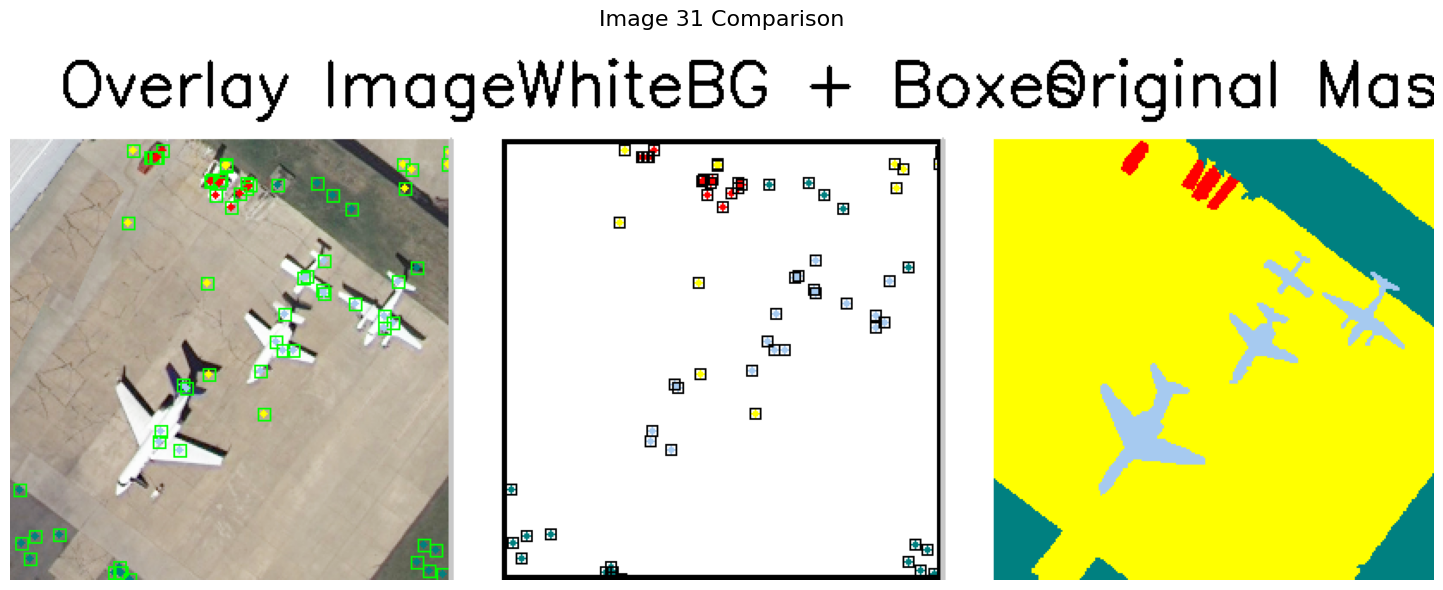

In [7]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def create_comparison_image_31(overlay_folder, whitebg_folder, orig_mask_folder, output_path, base_name="31", gap_size=20):
    """
    Create a horizontal composite of 3 images for image 31 with gaps between them:
    1. Overlay image (overlay_31.png)
    2. Point mask with white background (31.png)
    3. Original mask (31.png)
    """
    
    # Define the specific filenames with different naming patterns
    overlay_filename = f"overlay_{base_name}.png"  # overlay_31.png
    whitebg_filename = f"{base_name}.png"          # 31.png
    orig_mask_filename = f"{base_name}.png"        # 31.png
    
    # Construct full paths
    overlay_path = os.path.join(overlay_folder, overlay_filename)
    whitebg_path = os.path.join(whitebg_folder, whitebg_filename)
    orig_mask_path = os.path.join(orig_mask_folder, orig_mask_filename)
    
    print(f"📁 Looking for files:")
    print(f"   Overlay: {overlay_path}")
    print(f"   WhiteBG: {whitebg_path}")
    print(f"   Orig Mask: {orig_mask_path}")
    
    # Check if all files exist
    if not os.path.exists(overlay_path):
        print(f"❌ Overlay file not found: {overlay_path}")
        return
    if not os.path.exists(whitebg_path):
        print(f"❌ WhiteBG file not found: {whitebg_path}")
        return
    if not os.path.exists(orig_mask_path):
        print(f"❌ Original mask file not found: {orig_mask_path}")
        return
    
    try:
        # Read all three images
        overlay_img = cv2.imread(overlay_path)
        whitebg_img = cv2.imread(whitebg_path)
        orig_mask_img = cv2.imread(orig_mask_path)
        
        if overlay_img is None:
            print("❌ Error reading overlay image")
            return
        if whitebg_img is None:
            print("❌ Error reading whitebg image")
            return
        if orig_mask_img is None:
            print("❌ Error reading original mask image")
            return
        
        print(f"✅ Successfully loaded all images:")
        print(f"   Overlay shape: {overlay_img.shape}")
        print(f"   WhiteBG shape: {whitebg_img.shape}")
        print(f"   Orig Mask shape: {orig_mask_img.shape}")
        
        # Convert BGR to RGB for display
        overlay_rgb = cv2.cvtColor(overlay_img, cv2.COLOR_BGR2RGB)
        whitebg_rgb = cv2.cvtColor(whitebg_img, cv2.COLOR_BGR2RGB)
        orig_mask_rgb = cv2.cvtColor(orig_mask_img, cv2.COLOR_BGR2RGB)
        
        # Resize images to have the same height (maintain aspect ratio)
        target_height = min(overlay_rgb.shape[0], whitebg_rgb.shape[0], orig_mask_rgb.shape[0])
        
        def resize_to_height(img, height):
            h, w = img.shape[:2]
            scale = height / h
            new_w = int(w * scale)
            return cv2.resize(img, (new_w, height))
        
        overlay_resized = resize_to_height(overlay_rgb, target_height)
        whitebg_resized = resize_to_height(whitebg_rgb, target_height)
        orig_mask_resized = resize_to_height(orig_mask_rgb, target_height)
        
        # Create white gaps between images
        gap = np.ones((target_height, gap_size, 3), dtype=np.uint8) * 255  # White gap
        
        # Combine images horizontally with gaps
        composite = np.hstack([
            overlay_resized, 
            gap,  # Gap after first image
            whitebg_resized, 
            gap,  # Gap after second image
            orig_mask_resized
        ])
        
        # Add labels to the composite image
        label_height = 50
        composite_with_labels = np.ones((composite.shape[0] + label_height, composite.shape[1], 3), dtype=np.uint8) * 255
        
        # Place the composite image
        composite_with_labels[label_height:, :] = composite
        
        # Add text labels
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 1.2
        thickness = 2
        color = (0, 0, 0)  # Black text
        
        # Calculate label positions (accounting for gaps)
        w1 = overlay_resized.shape[1]
        w2 = whitebg_resized.shape[1]
        w3 = orig_mask_resized.shape[1]
        
        # Position labels under each image (accounting for gaps)
        label1_x = w1 // 2
        label2_x = w1 + gap_size + w2 // 2
        label3_x = w1 + gap_size + w2 + gap_size + w3 // 2
        
        cv2.putText(composite_with_labels, "Overlay Image", (label1_x - 100, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "WhiteBG + Boxes", (label2_x - 120, 30), font, font_scale, color, thickness)
        cv2.putText(composite_with_labels, "Original Mask", (label3_x - 100, 30), font, font_scale, color, thickness)
        
        # Add separator lines at the gap positions
        line_color = (200, 200, 200)  # Light gray lines
        line1_x = w1
        line2_x = w1 + gap_size + w2
        
        cv2.line(composite_with_labels, (line1_x, label_height), (line1_x, composite_with_labels.shape[0]), line_color, 2)
        cv2.line(composite_with_labels, (line2_x, label_height), (line2_x, composite_with_labels.shape[0]), line_color, 2)
        
        # Save the composite image
        cv2.imwrite(output_path, cv2.cvtColor(composite_with_labels, cv2.COLOR_RGB2BGR))
        print(f"✅ Composite image with gaps saved: {output_path}")
        
        # Display the image
        plt.figure(figsize=(20, 6))
        plt.imshow(composite_with_labels)
        plt.axis('off')
        plt.title(f'Image {base_name} Comparison', fontsize=16, pad=20)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"❌ Error creating composite: {str(e)}")
        import traceback
        traceback.print_exc()

def check_all_files_exist(overlay_folder, whitebg_folder, orig_mask_folder, base_name="31"):
    """
    Check if all required files exist with correct naming patterns
    """
    overlay_path = os.path.join(overlay_folder, f"overlay_{base_name}.png")  # overlay_31.png
    whitebg_path = os.path.join(whitebg_folder, f"{base_name}.png")          # 31.png
    orig_mask_path = os.path.join(orig_mask_folder, f"{base_name}.png")      # 31.png
    
    print("🔍 Checking if all files exist:")
    print(f"   Overlay (overlay_{base_name}.png): {overlay_path} - {'✅ EXISTS' if os.path.exists(overlay_path) else '❌ MISSING'}")
    print(f"   WhiteBG ({base_name}.png): {whitebg_path} - {'✅ EXISTS' if os.path.exists(whitebg_path) else '❌ MISSING'}")
    print(f"   Orig Mask ({base_name}.png): {orig_mask_path} - {'✅ EXISTS' if os.path.exists(orig_mask_path) else '❌ MISSING'}")
    
    return all([os.path.exists(overlay_path), os.path.exists(whitebg_path), os.path.exists(orig_mask_path)])

# Usage
if __name__ == "__main__":
    # Define your folder paths
    overlay_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_orig_overlay_train_images"  # Contains overlay_31.png
    whitebg_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_whitebg_border_boxes_enhanced"  # Contains 31.png (white background + boxes)
    orig_mask_folder = "/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_masks"  # Contains 31.png (original mask)
    
    # Output path for the composite image
    output_path = "image_31_comparison_with_gaps.png"
    
    # First, check if all files exist
    if check_all_files_exist(overlay_folder, whitebg_folder, orig_mask_folder, base_name="31"):
        print("\n🎯 All files found! Creating composite image with gaps...")
        # Create the composite image
        create_comparison_image_31(
            overlay_folder=overlay_folder,
            whitebg_folder=whitebg_folder, 
            orig_mask_folder=orig_mask_folder,
            output_path=output_path,
            base_name="31",
            gap_size=30  # Adjust gap size as needed (pixels)
        )
    else:
        print("\n❌ Some files are missing. Please check the paths above.")
        
        # Let's see what files actually exist in each folder
        print("\n📂 Actual files in folders:")
        print(f"Overlay folder files containing '31': {[f for f in os.listdir(overlay_folder) if '31' in f]}")
        print(f"WhiteBG folder files containing '31': {[f for f in os.listdir(whitebg_folder) if '31' in f]}")
        print(f"Orig Mask folder files containing '31': {[f for f in os.listdir(orig_mask_folder) if '31' in f]}")